# BESS-Optimierung am Day-Ahead-Markt mit PyPSA

<div style="
    background:rgba(255,255,255,0.055);
    border:1px solid rgba(255,255,255,0.14);
    border-left:4px solid rgba(160,160,160,0.55);
    border-radius:8px;
    padding:10px 14px;
    margin:10px 0 14px 0;
    line-height:1.35;
">

<p style="margin:0 0 8px 0;">
<span style="color:#ffffff; font-weight:400; background:rgba(66,165,245,0.28); padding:2px 7px; border-radius:6px;">Ziel</span>:
Das BESS-Optimierungsmodell wird mit PyPSA auf Basis der Day-Ahead-Preise von 2025 optimiert. Dafür wird die Methode Rolling Horizon verwendet.
</p>

<p style="margin:0;">
<span style="color:#ffffff; font-weight:400; background:rgba(66,165,245,0.28); padding:2px 7px; border-radius:6px;">Zielgröße</span>:
Nettoerlös = Erlöse<sub>Entladung</sub> − Kosten<sub>Ladung</sub>
<span style="color:rgba(255,255,255,0.78);">(Arbitrage am Day-Ahead-Markt)</span>
</p>

</div>






| <div style="text-align:center;"><span style="color:#ffffff; font-weight:400; background:rgba(66, 165, 245, 0.28); padding:2px 6px; border-radius:5px;">Parameter</span></div> | <div style="text-align:center;"><span style="color:#ffffff; font-weight:400; background:rgba(66, 165, 245, 0.28); padding:2px 6px; border-radius:5px;">Wert</span></div> |
|---|---:|
| Speicherkapazität: $E_{max}$ | 2 MWh |
| Lade-/ Entladeleistung: $P_{max}$ | 1 MW |
| Wirkungsgrad: $\eta_{Laden/Entladen}$ | 90 % |
| Startfüllstand: $SOC_{Start}$ | 50 % = 1 MWh |
| Endfüllstand: $SOC_{Ende}$ | 50 % = 1 MWh |






**Grenzen des Modells**

Das Modell berücksichtigt nicht: Batteriealterung, Degradation, Netzentgelte, Steuern, Abgaben, Transaktionskosten, reale Gebotsstrategien und technische Detailrestriktionen --> Ergebnisse als theoretisches Erlöspotenzial unter idealisierten Annahmen

In [1]:
import pandas as pd
import pypsa

pd.set_option("display.precision", 3)

## Schritt 1: Daten laden und prüfen

Die Day-Ahead-Preise 2025 werden geladen und auf Zeitraum, Datenumfang und 15-Minuten-Auflösung geprüft.

In [ ]:
preise = (  # Variable
    pd.read_csv("../daten/dayahead_2025.csv", parse_dates=["timestamp"], index_col="timestamp")  # CSV lesen, Zeitstempel parsen (Python wandelt Text in richtiges Datenformat um) und als Index setzen
    .rename(columns={"dayahead €/MWh": "price"})  # Spalte umbenennen
)

preise.index = preise.index.tz_convert(None)  # Zeitzone entfernen

print(f"Zeitraum: {preise.index.min()} bis {preise.index.max()}")   # gibt den ersten und letzten Zeitpunkt der Zeitreihe aus
print(f"Werte: {len(preise)} | 15-Minuten-Auflösung: {ist_15min}")  # gibt die Anzahl der Preiswerte aus und zeigt, ob alle Zeitabstände 15 Minuten betragen

preise.head()  # zeigt die ersten fünf Zeilen/ Datenpunkte der Zeitreihe an

Zeitraum: 2024-12-31 23:00:00 bis 2025-12-31 22:45:00
Anzahl Werte: 35040
Zeitschritt: 0 days 00:15:00


,price
timestamp,
2024-12-31 23:00:00,22.40
2024-12-31 23:15:00,-7.40
2024-12-31 23:30:00,-10.16
2024-12-31 23:45:00,-5.30
2025-01-01 00:00:00,5.54


## Schritt 2: Parameter

Die technischen Parameter des BESS werden festgelegt: Kapazität, Leistung, Wirkungsgrad sowie Start- und End-Ladezustand

In [ ]:
kapazität_mwh = 2.0     
p_lade_mw = 1.0          
p_entlade_mw = 1.0       
wirkungsgrad = 0.9       # Lade- und Entladewirkungsgrad je Richtung
soc_start_anteil = 0.5   
soc_ende_anteil = 0.5    

# Umrechnung von % in MWh
soc_start_mwh = soc_start_anteil * kapazität_mwh
soc_ende_mwh = soc_ende_anteil * kapazität_mwh

print(f"Kapazität: {kapazität_mwh} MWh")
print(f"Ladeleistung:  {p_lade_mw} / Entladeleistung: {p_entlade_mw} MW")
print(f"Wirkungsgrad (je Richtung): {wirkungsgrad:.0%}")
print(f"Start-SOC: {soc_start_mwh} MWh ({soc_start_anteil:.0%})")
print(f"End-SOC: {soc_ende_mwh} MWh ({soc_ende_anteil:.0%})")

Kapazitaet: 2.0 MWh
Ladeleistung / Entladeleistung: 1.0 / 1.0 MW
Wirkungsgrad (je Richtung): 90%
Start-SOC: 1.0 MWh (50%)
End-SOC (Vorgabe): 1.0 MWh (50%)


## Schritt 3: Rolling-Horizon-Fenster definieren


<div style="
    background:rgba(255,255,255,0.055);
    border:1px solid rgba(255,255,255,0.14);
    border-left:4px solid rgba(160,160,160,0.55);
    border-radius:8px;
    padding:10px 14px;
    margin:10px 0 14px 0;
    line-height:1.35;
">

<p style="margin:0 0 8px 0;">
<span style="color:#ffffff; font-weight:400; background:rgba(66,165,245,0.28); padding:2px 7px; border-radius:6px;">Rolling-Horizon</span>= Optimierungsmethode, bei der nicht das gesamte Jahr auf einmal optimert wird, sondern immer ein begrenzter Zeitraum betrachtet wird.

Für den BESS wird jeweils ein 48 h Zeitfenster optimiert. Davon werden aber nur die ersten 24 h übernommen, die restlichen 24 h dienen als Vorshau für den nächsten Tag.


<p style="margin:0 0 8px 0;">
<span style="color:#ffffff; font-weight:400; background:rgba(66,165,245,0.28); padding:2px 7px; border-radius:6px;">Ablauf des Rolling-Horizon-Verfahrens</span>: Der Speicherbetrieb wird schrittweise über das Jahr aufgebaut:

1. Das Modell betrachtet zunächst ein Zeitfenster (48 h)
2. Innerhalb dieses Fensters entscheidet der Optimierer:
      - wann die Batterie geladen wird
      - wann sie entladen wird
      - wie sich der Ladezustand entwickelt
      - wie der Erlös maximiert werden kann

3. Von den 48 h werden nur die ersten 24 Stunden übernommen, die restlichen Stunden diesen als Vorschau
4. Anschließend wird das Zeitfenster um 24 Stunden weitergeschoben
6. Der Ladezustand am Ende der übernommenen 24 Stunden wird als Startwert für das nächste Fenster verwendet

Der Vorgang wiederholt sich, bis das gesamte Jahr berechnet wurde

</p>
</div>

**Warum keine Optimierung für das ganze Jahr?**
- in der Realität unrealistisch, weil zukünftige Preise nur berengzt sichtbar sind

**Warum 48 Stunden optimieren, aber nur 24 Stunden übernehmen?**
Wenn das Modell nur 24 h sehen würde, wäre dies zu kurzsichtig

- der BESS könnte am Ende des Tages komplett entladen werden, weil das Modell nicht weiß, dass am nächsten tag noch höhere Preise kommen → schlechtere Entscheidungen werden getroffen
- 48 h Zeitfenster: Modell erkennt bereits, was am nächsten tag voraussichtlich passiere wird → Optimierung wird regelmäßig mit neuen Informationen aktualisiert

**Rolle des State of Charge (SOC)**

Der SOC beschreibt den Ladezustand der Batterie. In Rolling Horizon verbindet der SOC die einzelnen Zeitfenster miteinander. 
- Ladezustand am Ende eines übernommenen Zeitabschnitts wird zum Startwert des nächsten Zeitfensters
- ohne Weitergabe des SOC würde jedes neue Zeitfenster künstlich neu starten → verzerrt die Optimierung und ist physikalisch nicht korrekt
- der SOC sorgt dafür, dass der Speicherbetrieb über das gesamte Jahr konsistent und realistisch bleibt 

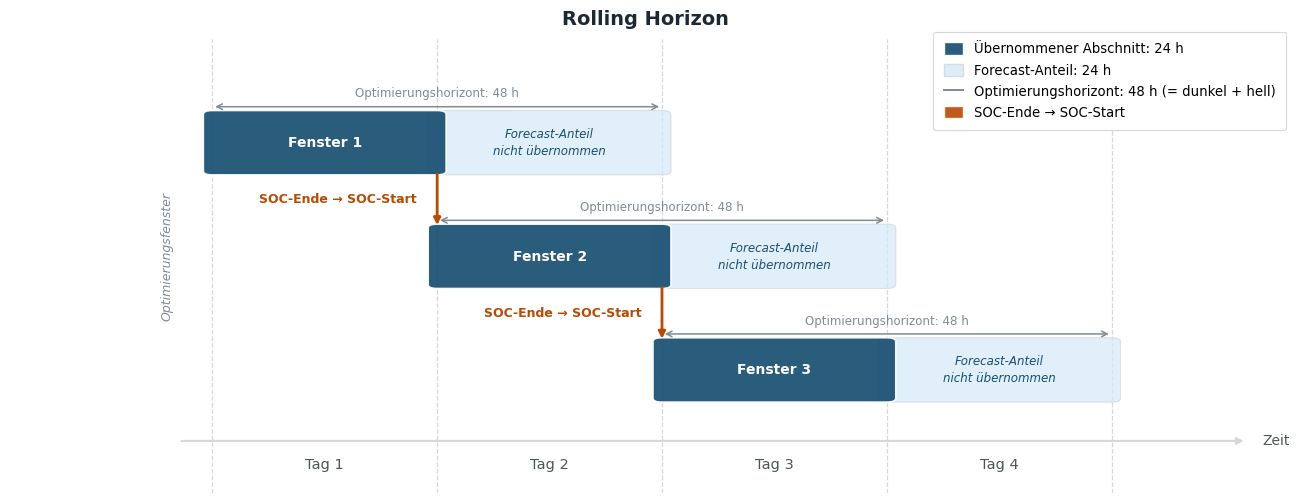

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

C_COMMIT   = "#1A4F72"   
C_FORECAST = "#D6EAF8"   
C_SOC      = "#BA4A00"   
C_BRACKET  = "#808B96"   
C_GRID     = "#D5D8DC"   
C_LABEL    = "#4D5656"   
C_TITLE    = "#1C2833"   

fig, ax = plt.subplots(figsize=(13, 5.0))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_xlim(-0.9, 4.75)
ax.set_ylim(-0.95, 3.85)
ax.axis("off")

def filled_rect(x, y, w, h, color, alpha=1.0, edge="white", lw=1.2):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.04",
        facecolor=color, edgecolor=edge, linewidth=lw, alpha=alpha, zorder=3,
    ))

ax.text(-0.20, 1.55, "Optimierungsfenster",
        ha="center", va="center", rotation=90,
        fontsize=9, color=C_BRACKET, fontstyle="italic")

for x in range(5):
    ax.axvline(x, color=C_GRID, linewidth=0.9, linestyle="--", zorder=1)

for i, label in enumerate(["Tag 1", "Tag 2", "Tag 3", "Tag 4"]):
    ax.text(i + 0.5, -0.65, label, ha="center", va="center",
            fontsize=10.5, color=C_LABEL)

ax.annotate("", xy=(4.60, -0.40), xytext=(-0.15, -0.40),
            arrowprops=dict(arrowstyle="-|>", color=C_GRID, lw=1.5))
ax.text(4.67, -0.40, "Zeit", ha="left", va="center", fontsize=10, color=C_LABEL)

windows = [(0, 2.75), (1, 1.55), (2, 0.35)]
H = 0.60

for i, (x0, yc) in enumerate(windows):
    yb = yc - H / 2
    filled_rect(x0 + 1, yb, 1, H, C_FORECAST, alpha=0.75, edge=C_GRID, lw=0.8)
    filled_rect(x0,     yb, 1, H, C_COMMIT,   alpha=0.93)

    ax.text(x0 + 0.5, yc, f"Fenster {i + 1}",
            ha="center", va="center",
            fontsize=10, color="white", fontweight="bold", zorder=5)
    ax.text(x0 + 1.5, yc, "Forecast-Anteil\nnicht übernommen",
            ha="center", va="center",
            fontsize=8.5, color="#1A4F72", fontstyle="italic",
            linespacing=1.4, zorder=5)

    by = yb + H + 0.08
    ax.annotate("", xy=(x0 + 2, by), xytext=(x0, by),
                arrowprops=dict(arrowstyle="<->", color=C_BRACKET,
                                lw=1.1, mutation_scale=10))
    ax.text(x0 + 1.0, by + 0.07, "Optimierungshorizont: 48 h",
            ha="center", va="bottom", fontsize=8.5, color=C_BRACKET)

for i in range(2):
    xp     = windows[i][0] + 1
    y_from = windows[i][1]   - H / 2
    y_to   = windows[i+1][1] + H / 2
    ax.annotate("", xy=(xp, y_to), xytext=(xp, y_from),
                arrowprops=dict(arrowstyle="-|>", color=C_SOC, lw=2.0), zorder=6)
    mid = (y_from + y_to) / 2
    ax.text(xp - 0.09, mid, "SOC-Ende → SOC-Start",
            ha="right", va="center",
            fontsize=9, color=C_SOC, fontweight="bold", zorder=6)

ph_c = mpatches.Patch(facecolor=C_COMMIT,   edgecolor="white", alpha=0.93,
                       label="Übernommener Abschnitt: 24 h")
ph_f = mpatches.Patch(facecolor=C_FORECAST, edgecolor=C_GRID,  alpha=0.85,
                       label="Forecast-Anteil: 24 h")
ln_b = Line2D([0], [0], color=C_BRACKET, lw=1.4,
               label="Optimierungshorizont: 48 h (= dunkel + hell)")
ph_s = mpatches.Patch(facecolor=C_SOC,      edgecolor="white", alpha=0.9,
                       label="SOC-Ende → SOC-Start")

leg = ax.legend(handles=[ph_c, ph_f, ln_b, ph_s],
                loc="upper right", fontsize=9.5, framealpha=1.0,
                edgecolor="#D5D8DC", bbox_to_anchor=(1.01, 1.03),
                handlelength=1.5, handleheight=1.05,
                borderpad=0.8, labelspacing=0.55)
leg.get_frame().set_linewidth(0.8)

ax.set_title("Rolling Horizon",
             fontsize=14, pad=10, color=C_TITLE, fontweight="600")

plt.tight_layout(pad=0.6)
plt.show()

In [ ]:
import logging      # Logging-Modul: steuert Ausgaben von Bibliotheken (z.B. Solver, PyPSA)
import warnings     # Warning-Modul: steuert Warnhinweise von Bibliotheken

# Solver-, PyPSA- und FutureWarning-Logausgaben für die Schleife unten reduzieren
logging.getLogger("pypsa").setLevel(logging.ERROR) # zeigt von PyPSA nur noch Fehlermeldungen an, keine Warnungen/ Infos
logging.getLogger("linopy").setLevel(logging.ERROR) # zeigt von Linopy nur noch Fehlermeldungen an, keine warnungen/ Infos
warnings.filterwarnings("ignore", category=FutureWarning) # unterdrückt Warnhinweise von Bibliotheken, damit das Notebook bei vielen Schleifendurchläufen nicht überflutet wird

# Rolling-Horizon-Parameter
horizont_tage = 2             # Länge des Optimierungsfensters in Tagen
schritt_tage = 1              # Schrittweite (übernommener Abschnitt) in Tagen
snapshots_pro_tag = 96        # 15 min x 24 h = 96 Werte pro Tag

horizont_snapshots = horizont_tage * snapshots_pro_tag      # rechnet die Länge des Zeitfensters in Zeitschritten um (96 Werte pro Tag * 2 Tage = 192 Zeitschritte)
schritt_snapshots = schritt_tage * snapshots_pro_tag        # rechnet die Schrittwerte in Zeitschritte um (96 Werte pro Tag * 1 Tag = 96 Zeitschritte)

print(f"Optimierungsfenster: {horizont_tage} Tage ({horizont_snapshots} Zeitschritte)")     # gibt zur Kontrolle aus, wie lang das Zeitfenster ist
print(f"Schrittweite: {schritt_tage} Tag ({schritt_snapshots} Zeitschritte)")               # gibt zur Kontrolle aus, wie wet das fenster nach jedem Lauf verschoben wurde

Optimierungsfenster: 2 Tage (192 Zeitschritte)
Schrittweite: 1 Tag (96 Zeitschritte)


### Schritt 4: PyPSA-Modell für ein Rolling-Horizon-Fenster definieren

<div style="
    background:rgba(255,255,255,0.055);
    border:1px solid rgba(255,255,255,0.14);
    border-left:4px solid rgba(160,160,160,0.55);
    border-radius:8px;
    padding:10px 14px;
    margin:10px 0 14px 0;
    line-height:1.35;
">

<p style="margin:0 0 8px 0;">
<span style="color:#ffffff; font-weight:400; background:rgba(66,165,245,0.28); padding:2px 7px; border-radius:6px;">PyPSA</span>= Python for Power System Analysis → Open-Source-Framework zur Modellierung und Optimierung von Energiesystemen (z.B. Stromnetze, Kraftwerke). Wird genutzt, um zu berechnen:

- wie Anlagen optimal betrieben werden
- wann Speicher laden oder entladen
- welche Kosten entstehen
- wie Stromflüsse im System aussehen
- wie ein Energiesystem ausgebaut werden könnte

Für die mathematische Optimierung brauch PyPSA: Preise, Batteriedaten, technische Grenzem und eine Zielfunktion → Solver berechnet daraus den optimalen Speicherfahrplan

**Bestandteile**

- Network = das gesamte Energiesystemmodell → Modellcontainer, in dem alle Komponenten gespeichert werden
- Snapshots =  Zeitpunkte der Optimierung (15-Minuten-Zeitschritte) → in einem Zeitpunkt kann das Modell entscheiden: laden, entladen oder nichts tun
- Bus = zentraler Knotenpunkt im Modell: alle Komponenten (z.B. Generatoren, Speicher, Lasten, Leistungen) werden an einen Bus angeschlossen → stellt sicher, dass Einspeisung und Verbrauch zusammenpassen 
- Generator = modelliert den Strommarkt → über ihn kann Strom zum Day-Ahead-Preis gekauft/ verkauft werden.
- StorageUnit = BESS
- Zeitreihen = Day-Ahead-Preise
- Solver = löst das mathematische Optimierungsproblem → berechnet, welche Entscheidung in jedem Zeitschritt optimal ist

Im Rolling-Horizon-Verfahren wird dieses PyPSA-Modell immer wieder für neue Preisfenster aufgebaut und mit dem aktualisierten SOC weitergeführt.

</p>
</div>

In [ ]:
def baue_netz_fenster(preise_fenster, soc_start):       # Funktion
    n = pypsa.Network()
    n.set_snapshots(preise_fenster.index)           # setzt die Zeitpunkte des Preisfensters als Optimierungszeitpunkte
    n.snapshot_weightings.loc[:, :] = 0.25          # 15 min pro Zeitschritt 

    n.add("Bus", "Knotenpunkt")     # Generator und StorageUnit werden angeschlossen

    n.add(
        "Generator",
        "Markt",
        bus="Knotenpunkt",
        p_nom=100,                  # sehr hohe Nennleistung, damit der Markt nie limitiert wird
        p_min_pu=-1,                # sehr niedrige min. Leistung ``-``
        p_max_pu=1,                 # sehr hohe max. Leistung ``-``
        marginal_cost=0,            # sehr niedrige Grenzkosten ``-``
    )
    n.generators_t.marginal_cost["Markt"] = preise_fenster["price"].values     # setzt die Day-Ahead-Preise als zeitabhängige Kosten/ Erlöse für den Generator

    n.add(
        "StorageUnit",
        "BESS",
        bus="Knotenpunkt",
        p_nom=p_entlade_mw,
        p_min_pu=-(p_lade_mw / p_entlade_mw),   
        max_hours=kapazität_mwh / p_entlade_mw,     # Speicherdauer: Kapazität / Entladeleistung
        efficiency_store=wirkungsgrad,
        efficiency_dispatch=wirkungsgrad,
        state_of_charge_initial=soc_start,
        cyclic_state_of_charge=False,               # SOC muss am Fensterende nicht automatisch dem Start-SOC entsprechen
    )
    return n                                        # gibt das fertige PyPSA-Netzwerk zurück

## Schritt 5: Kennzahlen-Funktion definieren

Aus den Ergebnistabellen (`preis_eur_mwh`, `bess_leistung_mw`, `soc_mwh`) lassen sich
folgende Kennzahlen berechnen:

- **Nettoerlös**: Summe aus `bess_leistung_mw * preis_eur_mwh * dt`, mit `dt = 0,25 h`.
- **Geladene / entladene Energie**: Summe der Lade- bzw. Entladeleistung über die Zeit.
- **Volllastzyklen**: entladene Energie / Speicherkapazität – gibt an, wie oft die
  Batterie rechnerisch vollständig entladen wurde.
- **Mittlerer Lade-/Entladepreis**: energiegewichteter Durchschnittspreis während der
  Lade- bzw. Entladezeitpunkte.
- **Durchschnittlicher Spread**: mittlerer Entladepreis − mittlerer Ladepreis – der
  Preisunterschied, von dem die Batterie tatsächlich profitiert.

Die Funktion wird auf das Jahresergebnis (`jahresergebnis`) aus Schritt 5 angewendet.

In [ ]:
def berechne_kennzahlen(ergebnis_df, kapazitaet_mwh, dt_h=0.25):
    energie_mwh = ergebnis_df["bess_leistung_mw"] * dt_h  # + Entladung, - Ladung

    nettoerloes = (energie_mwh * ergebnis_df["preis_eur_mwh"]).sum()

    lade_maske = energie_mwh < 0
    entlade_maske = energie_mwh > 0

    geladene_energie = -energie_mwh[lade_maske].sum()
    entladene_energie = energie_mwh[entlade_maske].sum()

    volllastzyklen = entladene_energie / kapazitaet_mwh

    mittlerer_ladepreis = (
        ergebnis_df.loc[lade_maske, "preis_eur_mwh"] * -energie_mwh[lade_maske]
    ).sum() / geladene_energie
    mittlerer_entladepreis = (
        ergebnis_df.loc[entlade_maske, "preis_eur_mwh"] * energie_mwh[entlade_maske]
    ).sum() / entladene_energie

    spread = mittlerer_entladepreis - mittlerer_ladepreis

    return pd.Series({
        "Nettoerlös [€]": nettoerloes,
        "Geladene Energie [MWh]": geladene_energie,
        "Entladene Energie [MWh]": entladene_energie,
        "Volllastzyklen": volllastzyklen,
        "Mittlerer Ladepreis [€/MWh]": mittlerer_ladepreis,
        "Mittlerer Entladepreis [€/MWh]": mittlerer_entladepreis,
        "Durchschnittlicher Spread [€/MWh]": spread,
    })

## Schritt 6: Jahresbewertung mit Rolling-Horizon-Optimierung

Die Rolling-Horizon-Logik aus Schritt 3 (48h-Fenster, 24h-Schrittweite,
SOC-Übergabe) wird auf den **gesamten verfügbaren Datensatz**
(35.040 Viertelstunden-Werte = 365 Tage) angewendet.

- Für die ersten 364 Tage ist das Fenster wie gewohnt 48h lang.
- Für den **letzten Tag** reicht der Datensatz nicht mehr für ein volles 48h-Fenster –
  das Fenster wird auf den verbleibenden Tag verkürzt, und genau hier wird die
  **End-SOC-Bedingung** (SOC am letzten Snapshot = `soc_ende_mwh`) gesetzt.
- Da der Datensatz technisch bei 2024-12-31 23:00 (UTC) beginnt, deckt er nicht exakt
  das Kalenderjahr 2025 ab, sondern 365 durchgehende Tage ab diesem Zeitpunkt.

**Hinweis:** Diese Schleife löst 365 Optimierungsprobleme und dauert ca. 1–3 Minuten.
Solver-Ausgaben werden unterdrückt; alle 30 Tage erscheint ein Fortschritts-Update.

In [7]:
import contextlib
import io

anzahl_tage_jahr = len(preise) // snapshots_pro_tag
print(f"Simulationszeitraum: {anzahl_tage_jahr} Tage ({len(preise)} Zeitschritte)")

soc_aktuell_jahr = soc_start_mwh
jahres_teilergebnisse = []

for tag_index in range(anzahl_tage_jahr):
    start_pos = tag_index * snapshots_pro_tag
    ende_pos = min(start_pos + horizont_snapshots, len(preise))
    fenster_index = preise.index[start_pos:ende_pos]
    preise_fenster = preise.loc[fenster_index]

    n_fenster = baue_netz_fenster(preise_fenster, soc_start=soc_aktuell_jahr)

    # Letztes Fenster ist ggf. kuerzer als die Schrittweite (Ende des Datensatzes)
    commit_laenge = min(schritt_snapshots, len(fenster_index))
    commit_index = fenster_index[:commit_laenge]

    m = n_fenster.optimize.create_model()
    if tag_index == anzahl_tage_jahr - 1:
        # End-SOC-Bedingung am Ende des gesamten Simulationszeitraums
        soc_var = m.variables["StorageUnit-state_of_charge"]
        m.add_constraints(soc_var.loc[commit_index[-1], "BESS"] == soc_ende_mwh, name="End-SOC")

    with contextlib.redirect_stdout(io.StringIO()):
        n_fenster.optimize.solve_model(solver_name="highs", solver_options={"output_flag": False})

    teilergebnis = pd.DataFrame({
        "preis_eur_mwh": preise_fenster.loc[commit_index, "price"],
        "bess_leistung_mw": n_fenster.storage_units_t.p.loc[commit_index, "BESS"],
        "soc_mwh": n_fenster.storage_units_t.state_of_charge.loc[commit_index, "BESS"],
    })
    jahres_teilergebnisse.append(teilergebnis)

    soc_aktuell_jahr = n_fenster.storage_units_t.state_of_charge.loc[commit_index[-1], "BESS"]

    if (tag_index + 1) % 30 == 0 or tag_index == anzahl_tage_jahr - 1:
        print(f"Tag {tag_index + 1}/{anzahl_tage_jahr}: SOC = {soc_aktuell_jahr:.3f} MWh")

jahresergebnis = pd.concat(jahres_teilergebnisse)
print()
print(f"Anzahl Zeitschritte im Jahresergebnis: {len(jahresergebnis)}")

Simulationszeitraum: 365 Tage (35040 Zeitschritte)


Tag 30/365: SOC = 0.225 MWh


Tag 60/365: SOC = 0.225 MWh


Tag 90/365: SOC = 0.450 MWh


Tag 120/365: SOC = 0.225 MWh


...

Tag 270/365: SOC = 0.278 MWh


Tag 300/365: SOC = -0.000 MWh


Tag 330/365: SOC = -0.000 MWh


Tag 360/365: SOC = 1.603 MWh


Tag 365/365: SOC = 1.000 MWh

Anzahl Zeitschritte im Jahresergebnis: 35040


### Kennzahlen der Jahresbewertung

Die Funktion `berechne_kennzahlen` aus Schritt 4 wird auf das Jahresergebnis angewendet.

In [ ]:
kennzahlen_jahr = berechne_kennzahlen(jahresergebnis, kapazität_mwh)
kennzahlen_jahr["Volllastzyklen pro Tag"] = kennzahlen_jahr["Volllastzyklen"] / anzahl_tage_jahr

pd.DataFrame({f"Jahr ({anzahl_tage_jahr} Tage)": kennzahlen_jahr})

,Jahr (365 Tage)
Nettoerloes [EUR],127489.314
Geladene Energie [MWh],2445.209
Entladene Energie [MWh],1972.073
Volllastzyklen,986.037
Mittlerer Ladepreis [EUR/MWh],47.979
Mittlerer Entladepreis [EUR/MWh],124.137
Durchschnittlicher Spread [EUR/MWh],76.158
Volllastzyklen pro Tag,2.701


### Ergebnisse über das Jahr

State-of-Charge-Verlauf (Tagesmittel) und monatlicher Nettoerlös – zeigt saisonale
Muster in Preisvolatilität und Batteriegewinn über das Jahr.

Hinweis: Der ganz linke Balken im unteren Plot ist sehr klein – er entspricht den ersten 4 Viertelstunden-Werten des Datensatzes (2024-12-31 23:00-23:45), die durch die Monats-Gruppierung (`resample("ME")`) einen eigenen, fast leeren Monatsbalken bilden.

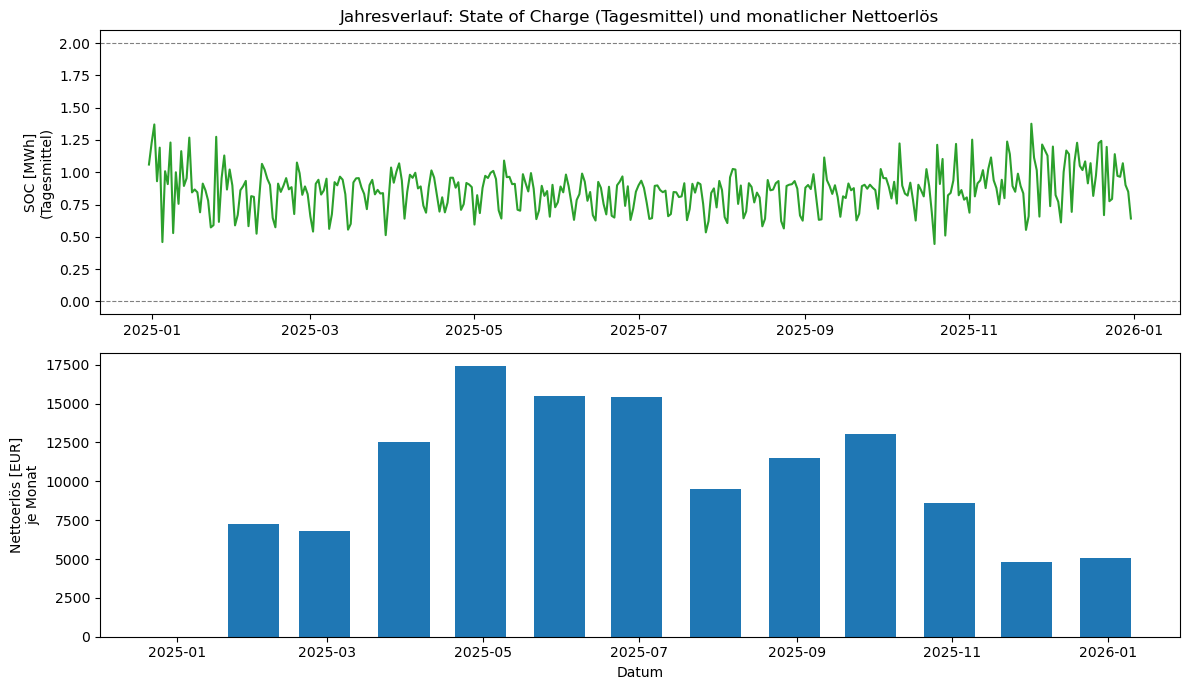

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# SOC-Verlauf (Tagesmittel)
soc_taeglich = jahresergebnis["soc_mwh"].resample("D").mean()
axes[0].plot(soc_taeglich.index, soc_taeglich, color="tab:green")
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].axhline(kapazität_mwh, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("SOC [MWh]\n(Tagesmittel)")
axes[0].set_title("Jahresverlauf: State of Charge (Tagesmittel) und monatlicher Nettoerlös")

# Monatlicher Nettoerlös
erloes_je_schritt = jahresergebnis["bess_leistung_mw"] * jahresergebnis["preis_eur_mwh"] * 0.25
erloes_monatlich = erloes_je_schritt.resample("ME").sum()
axes[1].bar(erloes_monatlich.index, erloes_monatlich, width=20, color="tab:blue")
axes[1].set_ylabel("Nettoerlös [EUR]\nje Monat")
axes[1].set_xlabel("Datum")

fig.tight_layout()
plt.show()

## Nächste Schritte

- Vergleich Rolling-Horizon-Ergebnis vs. "Perfect Foresight" (Optimierung des gesamten
  Jahres in einem Lauf) – zeigt den Effekt des begrenzten Vorhersagehorizonts
- Sensitivitätsanalyse: andere Fenstergrößen/Schrittweiten (z.B. 72h-Fenster, 12h-Schritt)
- Optional: Multi-Market-Optimierung, Netzrestriktionen, CO2-Preis-Szenarien
  (siehe Projektbeschreibung)